# Fashion-MNIST Image Classification with a Regularized CNN

Developed a reproducible Fashion-MNIST image-classification experiment with a regularized CNN and an MLP baseline. Used separate training, validation and official test partitions, training-only normalization, and validation-selected checkpoints. Added learning curves, class-level error analysis and documented results. The selected model achieved 93.14% held-out accuracy and 0.931 macro F1.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Compared a multilayer perceptron with a convolutional model using batch normalization, dropout, AdamW and cosine learning-rate decay. Used 48,000 training images and 12,000 validation images; selected model checkpoints using validation accuracy. The official 10,000-image test split was reserved for final evaluation. Normalization uses training pixels only.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,accuracy_95pct_wilson
MLP baseline,0.8652,0.8652,0.864112,0.864112,"[0.8583659821643959, 0.8717535351218433]"
Regularized CNN,0.9314,0.9314,0.931053,0.931053,"[0.9262781739004436, 0.9361905001337393]"


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.11.9',
 'numpy': '1.26.2',
 'pandas': '2.1.4',
 'sklearn': '1.3.2',
 'scipy': '1.11.4',
 'seed': 42,
 'torch': '2.2.0+cpu'}

Data fingerprint: see dataset checksums


## Figures

learning_curves.png


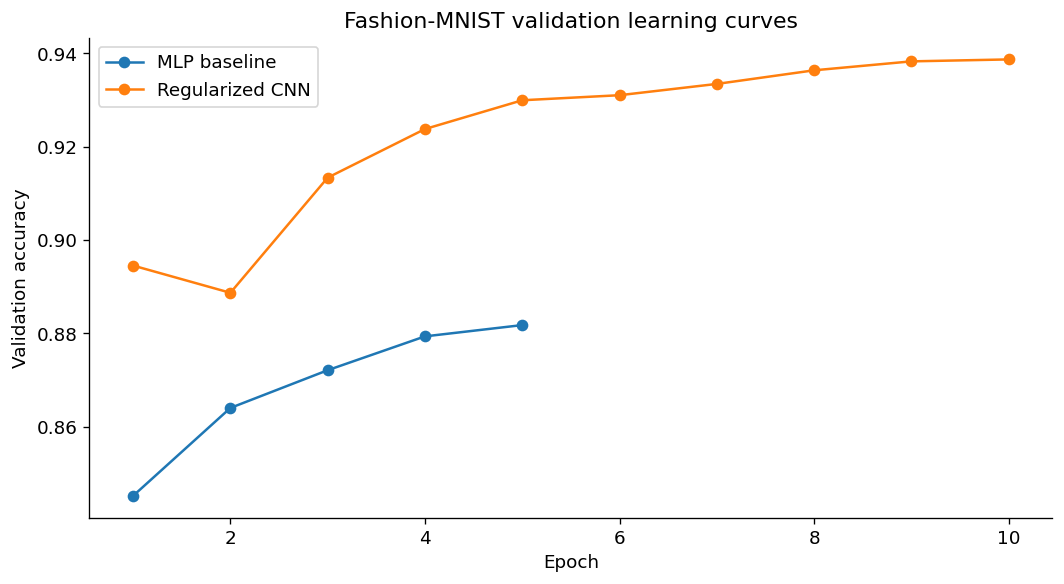

test_confusion_matrix.png


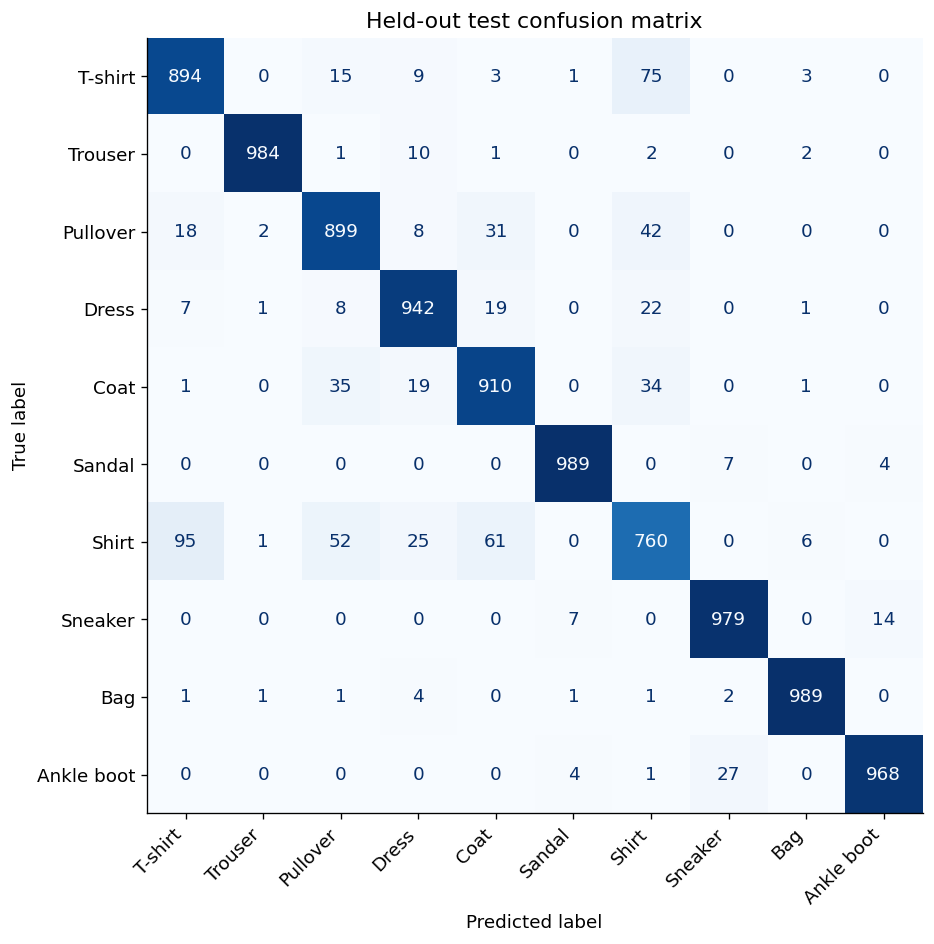

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

This is a small-image benchmark, not a validated classifier for real-world product photographs. MLP and CNN have different predefined training budgets. Tutorial notebooks were reference material; this refactor is a new reproducible experiment and does not claim a novel architecture.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --data data --out results --epochs 10'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)